In [1]:
import os


os.environ["RAY_ACCEL_ENV_VAR_OVERRIDE_ON_ZERO"] = "0"
os.environ["RAY_DEDUP_LOGS"] = "1"

In [2]:
# %%
import matplotlib.pyplot as plt
import numpy as np
import ray
import pandas as pd


from mpl_toolkits.mplot3d import Axes3D

from starforge.blackholes.parameters_recover.parameters_recovery import (
    ParametersRecoveryRemote
)

from starforge.blackholes.parameters_recover.metrics import (
    nrmse_percent,
    smape_percent,
    stabilized_mape_percent,
)

from starforge.blackholes.accretionrate.blackholesaccretionrate import (
    ParameterAccretionRate
)

from starforge.blackholes.parameters_recover.utils import (
    add_noise_to_data,
    gaussian_sum_from_p,
    make_bounds_for_gaussians,
)

from starforge.blackholes.parameters_recover.schemes import (
    GridParameters
)

In [3]:
if ray.is_initialized() is False:
    ray.init(ignore_reinit_error=True)

2026-05-21 11:10:11,997	INFO worker.py:2004 -- Started a local Ray instance. View the dashboard at http://127.0.0.1:8267 


In [4]:
# ============================================================
# GRID
# ============================================================

mbh_steps = 25

grid_params = GridParameters(
    mbh_steps=mbh_steps,
    z_steps=mbh_steps * 100
)

ln_mbh_grid = np.linspace(
    grid_params.mbh_i,
    grid_params.mbh_f,
    grid_params.mbh_steps
)

In [5]:
# %%
# ============================================================
# BENCHMARK INITIAL CONDITION
# ============================================================

benchmark_params = np.array([
    3.3e-02,
    8.2e-03,
    5.4e-02,
    1.07e+01,
    1.29e+01,
    1.21e+01,
    6.93e-01,
    1.05e+00,
    7.47e-01
])

initial_condition = gaussian_sum_from_p(
    benchmark_params,
    ln_mbh_grid,
    n_gauss=3
)

In [6]:
# %%
# ============================================================
# PHYSICAL MODEL PARAMETERS
# ============================================================

accretion_params = ParameterAccretionRate(
    mbh_par=2e11,
    alpha_par=3e-1,
    tau_par=5e9,
    eta=0.1,
    t_q=1e9,
    b_1=0.1,
    b_2=0.1,
)

In [7]:
# ============================================================
# FORWARD SOLVER
# ============================================================

objective_function = ParametersRecoveryRemote.remote(
    grid_params=grid_params
)

In [8]:
# %%
# ============================================================
# REFERENCE FINAL BHMF
# ============================================================

reference_outputs = ray.get(
    objective_function.directly_problem.remote(
        initial_condition,
        accretion_params
    )
)

reference_final = reference_outputs.n_final

In [9]:
# ============================================================
# SYNTHETIC OBSERVATION
# ============================================================

noise_level = 0.01

target_data = add_noise_to_data(
    data=reference_final,
    mu=0.0,
    sigma=noise_level,
    rho=0.5,
    alpha=0.5,
    seed=52,
    noise_type='mixed'
)

In [10]:
# %%
# ============================================================
# OPTIMIZATION BOUNDS
# ============================================================

bounds = make_bounds_for_gaussians(
    x_min=6.0,
    x_max=15.0,
    preferred_center_index=2,
    preferred_center=12.0,
    preferred_center_radius=1.0,
    Amax=1e-1,
    sigma_min=0.01,
    sigma_max=5.0,
    sigma_max_preferred=1.0,
    K=3
)

bounds.extend([
    (0.5, 5.0),     # mbh_par
    (1.0, 10.0),    # tau_par
    (0.01, 0.6),    # alpha_par
    (0.01, 0.5),    # eta
    (0.5, 5.0),     # t_q
    (0.01, 0.5),    # b_1
    (0.01, 0.5),    # b_2
])

In [11]:
# %%
recovery = ParametersRecoveryRemote.remote(
    grid_params=grid_params
)

In [12]:
return_components = True

In [14]:
# %%
# ============================================================
# L-SURFACE COMPUTATION
# ============================================================

alpha_p_values = np.logspace(-4, 0, 5)
alpha_theta_values = np.logspace(-4, 0, 5)

results = []

for alpha_p in alpha_p_values:
    for alpha_theta in alpha_theta_values:

        print(
            f"Running optimization with "
            f"alpha_p={alpha_p:.2e}, "
            f"alpha_theta={alpha_theta:.2e}"
        )

        # ----------------------------------------------------
        # Optimization
        # ----------------------------------------------------

        best = ray.get(
            recovery.optimizer.remote(
                bounds=bounds,
                target_data=target_data,
                weight_p=alpha_p,
                weight_theta=alpha_theta,
                n_max=1,
                use_de=True,
                fast_mode=True,
            )
        )

        # ----------------------------------------------------
        # Diagnostics
        # ----------------------------------------------------

        diagnostics = ray.get(
            recovery.objective_function.remote(
                np.array(best.x),
                target_data,
                weight_p=alpha_p,
                weight_theta=alpha_theta,
                return_components=True
            )
        )

        results.append({
            "alpha_p": alpha_p,
            "alpha_theta": alpha_theta,
            "objective": diagnostics["objective"],
            "misfit": diagnostics["misfit"],
            "R_p": diagnostics["R_p"],
            "R_theta": diagnostics["R_theta"],
            "best_parameters": np.array(best.x),
        })

Running optimization with alpha_p=1.00e-03, alpha_theta=1.00e-03
(ParametersRecovery pid=535480) Starting optimization ...
(ParametersRecovery pid=535480) Objective value: 1.566169e+02 | Context: Minimum detected in annealing process
(ParametersRecovery pid=535480) Objective value: 1.422974e+02 | Context: Minimum detected in annealing process
(ParametersRecovery pid=535480) Objective value: 1.405801e+02 | Context: Minimum detected in annealing process


(ParametersRecovery pid=535480) /home/eduardo/Projects/starforge2/.venv/lib/python3.12/site-packages/scipy/optimize/_numdiff.py:686: RuntimeWarning: invalid value encountered in subtract
(ParametersRecovery pid=535480)   df = [f_eval - f0 for f_eval in f_evals]


(ParametersRecovery pid=535480) Objective value: 1.321940e+02 | Context: Minimum detected in annealing process
(ParametersRecovery pid=535480) Objective value: 1.317938e+02 | Context: Minimum detected in annealing process
(ParametersRecovery pid=535480) Objective value: 1.313693e+02 | Context: Minimum detected in annealing process
(ParametersRecovery pid=535480) Objective value: 1.067948e+02 | Context: Minimum detected in annealing process
(ParametersRecovery pid=535480) Objective value: 1.066079e+02 | Context: Minimum detected in annealing process
(ParametersRecovery pid=535480) Objective value: 1.019398e+02 | Context: Minimum detected in annealing process
(ParametersRecovery pid=535480) Objective value: 9.594762e+01 | Context: Minimum detected in annealing process


KeyboardInterrupt: 

In [ ]:
# %%
# ============================================================
# SURFACE ARRAYS
# ============================================================

alpha_p_grid = np.array([r["alpha_p"] for r in results])
alpha_theta_grid = np.array([r["alpha_theta"] for r in results])

misfit_grid = np.array([r["misfit"] for r in results])

X = np.log10(alpha_p_grid)
Y = np.log10(alpha_theta_grid)
Z = np.log10(misfit_grid + 1e-15)

# Reshape to structured grid
X = X.reshape(len(alpha_p_values), len(alpha_theta_values))
Y = Y.reshape(len(alpha_p_values), len(alpha_theta_values))
Z = Z.reshape(len(alpha_p_values), len(alpha_theta_values))

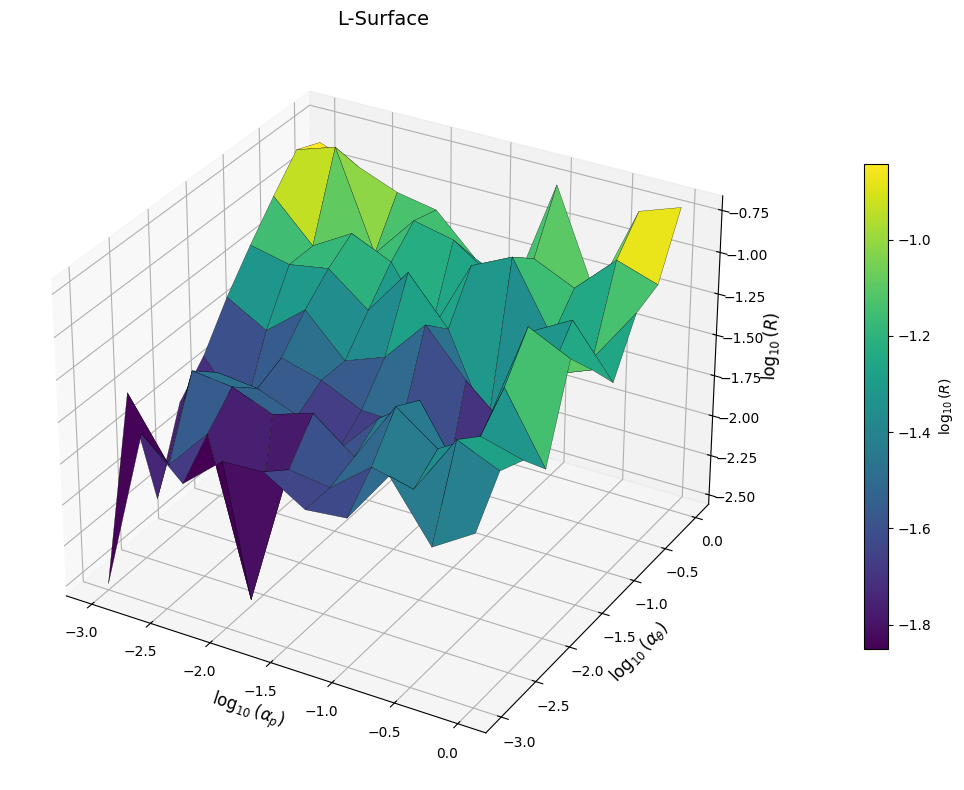

In [ ]:
# %%
# ============================================================
# L-SURFACE PLOT
# ============================================================

fig = plt.figure(figsize=(11, 8))

ax = fig.add_subplot(111, projection="3d")

surface = ax.plot_surface(
    X,
    Y,
    Z,
    cmap="viridis",
    edgecolor="k",
    linewidth=0.2,
    antialiased=True
)

ax.set_xlabel(r"$\log_{10}(\alpha_p)$", fontsize=12)
ax.set_ylabel(r"$\log_{10}(\alpha_\theta)$", fontsize=12)
ax.set_zlabel(r"$\log_{10}(R)$", fontsize=12)

ax.set_title("L-Surface", fontsize=14)

fig.colorbar(
    surface,
    ax=ax,
    shrink=0.65,
    pad=0.1,
    label=r"$\log_{10}(R)$"
)

plt.tight_layout()
plt.show()

In [ ]:
# %%

df = pd.DataFrame(results)

# ------------------------------------------------------------
# Log quantities
# ------------------------------------------------------------

epsilon = 1e-15

df["log_alpha_p"] = np.log10(df["alpha_p"] + epsilon)
df["log_alpha_theta"] = np.log10(df["alpha_theta"] + epsilon)

df["log_R"] = np.log10(df["misfit"] + epsilon)
df["log_R_p"] = np.log10(df["R_p"] + epsilon)
df["log_R_theta"] = np.log10(df["R_theta"] + epsilon)

df["log_J"] = np.log10(df["objective"] + epsilon)

In [ ]:
# %%
# ------------------------------------------------------------
# Pareto frontier
# ------------------------------------------------------------

costs = df[
    [
        "misfit",
        "R_p",
        "R_theta",
    ]
].values

n_points = costs.shape[0]

is_pareto = np.ones(n_points, dtype=bool)

for i in range(n_points):

    if not is_pareto[i]:
        continue

    for j in range(n_points):

        if i == j:
            continue

        dominates = (
            np.all(costs[j] <= costs[i]) and
            np.any(costs[j] < costs[i])
        )

        if dominates:

            is_pareto[i] = False
            break

df["pareto"] = is_pareto

print(
    f"Pareto-optimal points: "
    f"{df['pareto'].sum()} / {len(df)}"
)

Pareto-optimal points: 17 / 100


In [ ]:
# %%
# ------------------------------------------------------------
# Pareto subset
# ------------------------------------------------------------

pareto_df = (
    df[df["pareto"]]
    .copy()
    .reset_index(drop=False)
)

print(pareto_df[
    [
        "alpha_p",
        "alpha_theta",
        "misfit",
        "R_p",
        "R_theta",
        "objective",
    ]
])

     alpha_p  alpha_theta    misfit       R_p   R_theta  objective
0   0.001000     0.001000  0.003007  7.524681  6.771062   0.017302
1   0.001000     0.004642  0.005569  7.395904  5.803512   0.039903
2   0.010000     0.002154  0.003008  7.583905  5.748574   0.091232
3   0.046416     0.021544  0.020958  6.912708  5.756729   0.465843
4   0.100000     0.021544  0.007961  7.370558  5.446829   0.862365
5   0.100000     0.046416  0.033822  6.652366  5.674142   0.962429
6   0.100000     0.100000  0.013361  7.437253  4.356818   1.192768
7   0.215443     0.010000  0.018958  7.131002  5.390196   1.609188
8   0.215443     0.215443  0.041817  7.162526  4.360940   2.524472
9   0.215443     0.464159  0.062991  6.557884  4.094043   3.376130
10  0.215443     1.000000  0.044536  7.155586  4.406210   5.992371
11  0.464159     0.215443  0.036434  6.755644  4.475583   4.136362
12  1.000000     0.001000  0.030168  6.301827  5.861058   6.337856
13  1.000000     0.010000  0.029232  6.628990  6.400105   6.72

In [ ]:
# %%
# ------------------------------------------------------------
# Stability metric in parameter space
# ------------------------------------------------------------

parameter_matrix = np.vstack(
    pareto_df["best_parameters"].values
)

stability = []

for i in range(len(pareto_df)):

    current = parameter_matrix[i]

    distances = np.linalg.norm(
        parameter_matrix - current,
        axis=1
    )

    distances[i] = np.inf

    nearest_distance = distances.min()

    stability.append(nearest_distance)

pareto_df["stability"] = stability

In [ ]:
# %%
# ------------------------------------------------------------
# Empirical selection of regularization pair
# ------------------------------------------------------------

selected_lambda_p = 1e-2
selected_lambda_theta = 1e-2

selection_mask = (
    np.isclose(
        pareto_df["alpha_p"],
        selected_lambda_p
    )
    &
    np.isclose(
        pareto_df["alpha_theta"],
        selected_lambda_theta
    )
)

selected_candidates = pareto_df[
    selection_mask
]

if len(selected_candidates) == 0:

    raise ValueError(
        "Selected regularization pair not found "
        "inside Pareto set."
    )

best_row = selected_candidates.iloc[0]

print(
    "\nSelected regularization pair:\n"
)

print(best_row[
    [
        "alpha_p",
        "alpha_theta",
        "misfit",
        "R_p",
        "R_theta",
        "objective",
        "sensitivity",
    ]
])

In [ ]:
# %%
# ------------------------------------------------------------
# Recover selected parameters
# ------------------------------------------------------------

selected_parameters = best_row["best_parameters"]

print("\nRecovered parameters:\n")

for i, value in enumerate(selected_parameters):

    print(f"p[{i}] = {value:.6e}")

In [ ]:
# %%
# ------------------------------------------------------------
# Neighbor analysis around selected solution
# ------------------------------------------------------------

pareto_df["distance"] = np.sqrt(
    (
        pareto_df["log_alpha_p"] -
        best_row["log_alpha_p"]
    )**2
    +
    (
        pareto_df["log_alpha_theta"] -
        best_row["log_alpha_theta"]
    )**2
)

neighbors = (
    pareto_df
    .sort_values("distance")
    .head(7)
    .copy()
)

neighbors = neighbors.sort_values(
    by=[
        "log_alpha_p",
        "log_alpha_theta",
    ]
)

print(neighbors[
    [
        "log_alpha_p",
        "log_alpha_theta",
        "log_R",
        "log_R_p",
        "log_R_theta",
        "log_J",
        "sensitivity",
    ]
])

In [ ]:
# %%
# ------------------------------------------------------------
# 3D Pareto visualization
# ------------------------------------------------------------

fig = plt.figure(figsize=(11, 8))

ax = fig.add_subplot(111, projection="3d")

non_pareto = df[~df["pareto"]]

ax.scatter(
    non_pareto["log_R_p"],
    non_pareto["log_R_theta"],
    non_pareto["log_R"],
    alpha=0.3,
    label="Dominated solutions"
)

ax.scatter(
    pareto_df["log_R_p"],
    pareto_df["log_R_theta"],
    pareto_df["log_R"],
    s=80,
    label="Pareto frontier"
)

ax.scatter(
    best_row["log_R_p"],
    best_row["log_R_theta"],
    best_row["log_R"],
    s=200,
    marker="*",
    label="Adopted regularization pair"
)

ax.set_xlabel(r"$\log_{10}(R_p)$")
ax.set_ylabel(r"$\log_{10}(R_\theta)$")
ax.set_zlabel(r"$\log_{10}(R)$")

ax.set_title(
    "Pareto Frontier in Objective Space"
)

ax.legend()

plt.tight_layout()
plt.show()

In [ ]:
# %%
# ------------------------------------------------------------
# 2D hyperparameter map
# ------------------------------------------------------------

fig, ax = plt.subplots(
    figsize=(9, 7)
)

scatter = ax.scatter(
    df["log_alpha_p"],
    df["log_alpha_theta"],
    c=df["log_R"],
    s=90,
    cmap="viridis",
)

ax.scatter(
    pareto_df["log_alpha_p"],
    pareto_df["log_alpha_theta"],
    s=180,
    facecolors="none",
    edgecolors="red",
    linewidths=2,
    label="Pareto"
)

ax.scatter(
    best_row["log_alpha_p"],
    best_row["log_alpha_theta"],
    s=300,
    marker="*",
    label="Adopted"
)

ax.set_xlabel(
    r"$\log_{10}(\lambda_p)$"
)

ax.set_ylabel(
    r"$\log_{10}(\lambda_\theta)$"
)

ax.set_title(
    "Hyperparameter Space"
)

cbar = plt.colorbar(scatter)

cbar.set_label(
    r"$\log_{10}(R)$"
)

ax.legend()

plt.tight_layout()
plt.show()

In [ ]:
# %%
# ------------------------------------------------------------
# Generate LaTeX table
# ------------------------------------------------------------

columns = [
    "log_alpha_p",
    "log_alpha_theta",
    "log_R",
    "log_R_theta",
    "log_R_p",
    "log_J",
    "sensitivity",
]

latex_rows = []

selected_log_alpha_p = np.log10(selected_lambda_p)
selected_log_alpha_theta = np.log10(selected_lambda_theta)

for _, row in neighbors.iterrows():

    is_selected = (
        np.isclose(
            row["log_alpha_p"],
            selected_log_alpha_p
        )
        and
        np.isclose(
            row["log_alpha_theta"],
            selected_log_alpha_theta
        )
    )

    if is_selected:

        values = [
            rf"\textbf{{{row[col]:.6f}}}"
            for col in columns
        ]

    else:

        values = [
            f"{row[col]:.6f}"
            for col in columns
        ]

    line = " & ".join(values) + r" \\"

    latex_rows.append(line)

latex_table = rf"""
\begin{{table}}
\centering

\caption{{
Representative Pareto-optimal solutions around the adopted
regularization regime.
The column ``Local Sensitivity'' corresponds to the minimum
Euclidean distance between neighboring Pareto-optimal parameter
vectors in the reconstruction space.
Smaller values indicate locally stable reconstructions under
perturbations of the regularization hyperparameters.
}}

\label{{tab:pareto_optimum}}

\resizebox{{\linewidth}}{{!}}{{
\begin{{tabular}}{{ccccccc}}
\hline

$\log \lambda_{{p}}$
&
$\log \lambda_{{\theta}}$
&
$\log R$
&
$\log R_{{\theta}}$
&
$\log R_{{p}}$
&
$\log J$
&
Sensitivity
\\

\hline

{chr(10).join(latex_rows)}

\hline
\end{{tabular}}
}}

\end{{table}}
"""

print(latex_table)

In [ ]:
# %%
# ------------------------------------------------------------
# Pareto frontier in objective space
# ------------------------------------------------------------

fig = plt.figure(figsize=(20, 8))

ax = fig.add_subplot(111, projection="3d")

# ------------------------------------------------------------
# Dominated solutions
# ------------------------------------------------------------

non_pareto = df[~df["pareto"]]

ax.scatter(
    non_pareto["log_R_p"],
    non_pareto["log_R_theta"],
    non_pareto["log_R"],
    s=45,
    alpha=0.25,
    label="Dominated solutions"
)

# ------------------------------------------------------------
# Pareto-optimal solutions
# ------------------------------------------------------------

ax.scatter(
    pareto_df["log_R_p"],
    pareto_df["log_R_theta"],
    pareto_df["log_R"],
    s=90,
    label="Pareto-optimal solutions"
)

# ------------------------------------------------------------
# Adopted regularization pair
# ------------------------------------------------------------

ax.scatter(
    best_row["log_R_p"],
    best_row["log_R_theta"],
    best_row["log_R"],
    s=260,
    marker="*",
    label="Adopted regularization pair"
)

# ------------------------------------------------------------
# Axis labels
# ------------------------------------------------------------

ax.set_xlabel(
    r"$\log_{10}(R_{p})$",
    fontsize=13,
    labelpad=12
)

ax.set_ylabel(
    r"$\log_{10}(R_{\theta})$",
    fontsize=13,
    labelpad=12
)

ax.set_zlabel(
    r"$\log_{10}(R)$",
    fontsize=13,
    labelpad=12
)

# ------------------------------------------------------------
# Title
# ------------------------------------------------------------

ax.set_title(
    "Pareto Frontier in Objective Space",
    fontsize=15,
    pad=18
)

# ------------------------------------------------------------
# View angle
# ------------------------------------------------------------

ax.view_init(
    elev=28,
    azim=100
)

# ------------------------------------------------------------
# Grid and legend
# ------------------------------------------------------------

ax.grid(True)

ax.legend(
    loc="upper left",
    fontsize=10
)

plt.tight_layout()

# ------------------------------------------------------------
# Save figure
# ------------------------------------------------------------

plt.savefig(
    "pareto_surface.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()